shape = (225, 225) dtype = uint8
min = 0 max = 255
mean = 130.6 std = 49.22


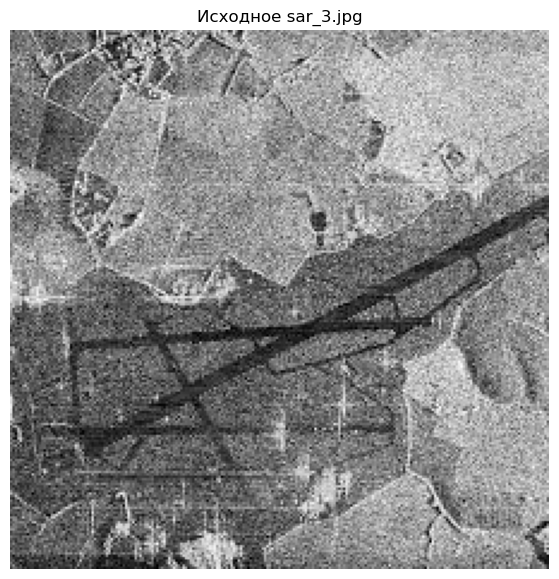

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

# Загрузка изображения
image = cv2.imread('sar_3.jpg')
if image is None:
    raise FileNotFoundError("Файл sar_3.jpg не найден в текущей папке")

# Конвертация в серый
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("shape =", image_gray.shape, "dtype =", image_gray.dtype)
print("min =", image_gray.min(), "max =", image_gray.max())
print("mean =", round(float(image_gray.mean()), 2),
      "std =", round(float(image_gray.std()), 2))

plt.figure(figsize=(8, 7))
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное sar_3.jpg')
plt.axis('off')
plt.show()

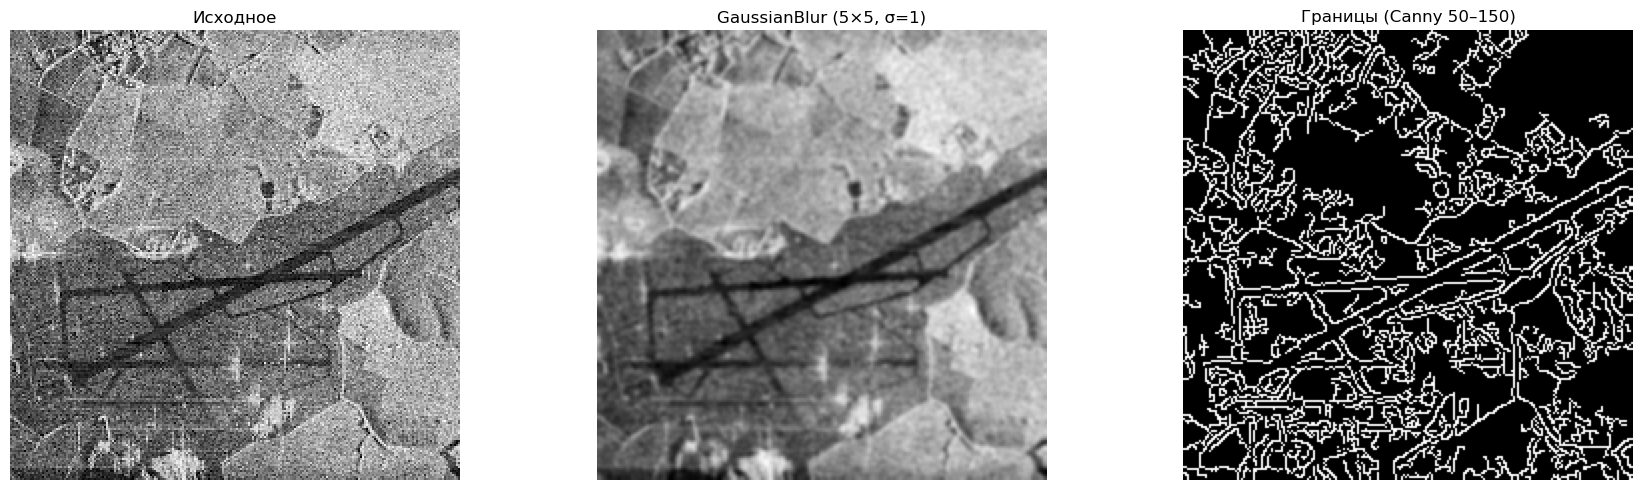

Количество пикселей границ: 10049


In [2]:
# Размытие для подавления спекл-шума
blurred = cv2.GaussianBlur(image_gray, (5, 5), 1.0)

# Выделение границ оператором Кэнни
edges = cv2.Canny(blurred, 50, 150, apertureSize=3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image_gray, cmap='gray'); axes[0].set_title('Исходное')
axes[1].imshow(blurred, cmap='gray');    axes[1].set_title('GaussianBlur (5×5, σ=1)')
axes[2].imshow(edges, cmap='gray');      axes[2].set_title('Границы (Canny 50–150)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

print("Количество пикселей границ:", int((edges > 0).sum()))

HoughLinesP: найдено сегментов: 103

Топ-15 самых длинных сегментов:
  # 1: L= 209.3  угол=   45.0°  ( 71,  1)→(219,149)
  # 2: L= 206.2  угол=  -28.1°  ( 40,166)→(222, 69)
  # 3: L= 197.2  угол=  -33.2°  ( 32,209)→(197,101)
  # 4: L= 147.6  угол=   24.8°  ( 35,  0)→(169, 62)
  # 5: L= 143.2  угол=   86.8°  ( 20, 63)→( 28,206)
  # 6: L= 138.4  угол=   60.1°  ( 49,103)→(118,223)
  # 7: L= 138.0  угол=    0.0°  (  7,197)→(145,197)
  # 8: L= 123.6  угол=   36.8°  (  2, 58)→(101,132)
  # 9: L= 116.1  угол=   88.0°  ( 26, 80)→( 30,196)
  #10: L= 113.0  угол=    0.0°  ( 33,196)→(146,196)
  #11: L= 108.3  угол=  -25.1°  ( 27,223)→(125,177)
  #12: L= 101.8  угол=   45.0°  ( 53, 69)→(125,141)
  #13: L= 101.8  угол=   45.0°  ( 29, 52)→(101,124)
  #14: L= 101.6  угол=  -28.8°  (129,127)→(218, 78)
  #15: L=  99.4  угол=  -28.9°  (133,126)→(220, 78)

После фильтрации по углу: осталось 73 сегментов

=== Топ-10 линий по оценке (длина × тёмность) ===
  # 1: оценка=  125.4  L= 206.2  угол= -28.1°  ср.я

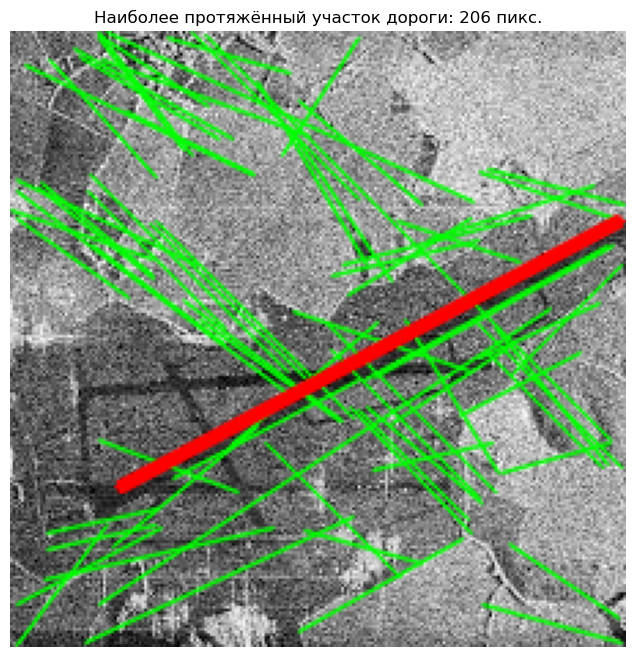

In [3]:
# === 1. HoughLinesP — вероятностное преобразование ===
linesP = cv2.HoughLinesP(edges,
                         rho=1,
                         theta=np.pi/180,
                         threshold=40,
                         minLineLength=40,
                         maxLineGap=8)

print("HoughLinesP: найдено сегментов:", 0 if linesP is None else len(linesP))

image_houghP = image.copy()
segments = []

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        length = math.hypot(x2 - x1, y2 - y1)
        angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
        segments.append((length, angle, (x1, y1, x2, y2)))

    print("\nТоп-15 самых длинных сегментов:")
    segments_sorted = sorted(segments, key=lambda s: s[0], reverse=True)
    for i, (L, ang, (x1, y1, x2, y2)) in enumerate(segments_sorted[:15]):
        print(f"  #{i+1:2}: L={L:6.1f}  угол={ang:7.1f}°  "
              f"({x1:3},{y1:3})→({x2:3},{y2:3})")

    # === 2. Фильтр по углу: оставляем диагональные линии (дорога) ===
    filtered = []
    for L, ang, coords in segments:
        a = ang
        if a > 90:  a -= 180
        if a < -90: a += 180

        if (10 < abs(a) < 60) and L > 40:
            filtered.append((L, a, coords))

    print(f"\nПосле фильтрации по углу: осталось {len(filtered)} сегментов")

    # === 3. Оценка «длина × тёмность линии» ===
    scored = []
    for L, ang, (x1, y1, x2, y2) in filtered:
        n_pts = max(2, int(L))
        xs = np.clip(np.linspace(x1, x2, n_pts).astype(int), 0, image_gray.shape[1]-1)
        ys = np.clip(np.linspace(y1, y2, n_pts).astype(int), 0, image_gray.shape[0]-1)
        mean_brightness = image_gray[ys, xs].mean()

        darkness = 255 - mean_brightness
        score = L * (darkness / 255)
        scored.append((score, L, ang, mean_brightness, (x1, y1, x2, y2)))

    scored.sort(reverse=True)

    print("\n=== Топ-10 линий по оценке (длина × тёмность) ===")
    for i, (sc, L, ang, bright, _) in enumerate(scored[:10]):
        print(f"  #{i+1:2}: оценка={sc:7.1f}  L={L:6.1f}  "
              f"угол={ang:6.1f}°  ср.яркость={bright:6.1f}")

    # === 4. Визуализация ===
    for L, ang, (x1, y1, x2, y2) in filtered:
        cv2.line(image_houghP, (x1, y1), (x2, y2), (0, 255, 0), 1, cv2.LINE_AA)

    best = scored[0]
    x1, y1, x2, y2 = best[4]
    cv2.line(image_houghP, (x1, y1), (x2, y2), (0, 0, 255), 3, cv2.LINE_AA)

    print(f"\n🏆 Наиболее протяжённый участок дороги:")
    print(f"   Длина       = {best[1]:.1f} пикс.")
    print(f"   Угол        = {best[2]:.1f}°")
    print(f"   Ср. яркость = {best[3]:.1f}")
    print(f"   Точки: ({x1},{y1}) → ({x2},{y2})")

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(image_houghP, cv2.COLOR_BGR2RGB))
    plt.title(f'Наиболее протяжённый участок дороги: {best[1]:.0f} пикс.')
    plt.axis('off')
    plt.show()
else:
    print("⚠️ HoughLinesP не нашёл сегментов. Уменьшите threshold.")

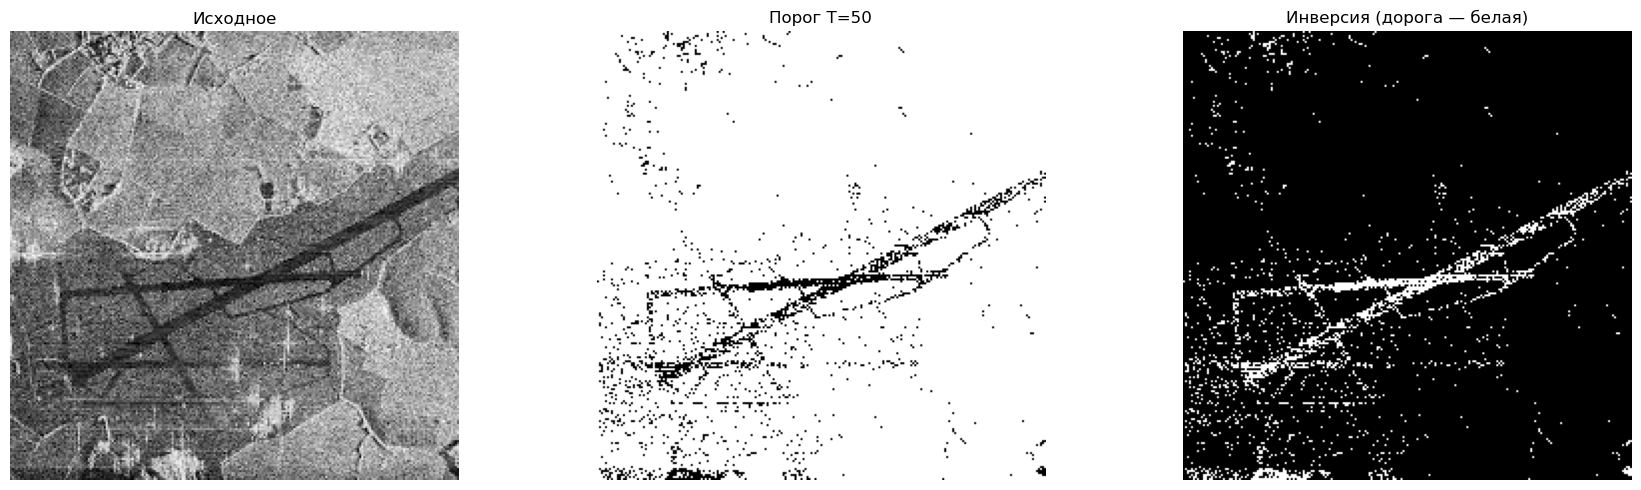

In [4]:
bin_img = copy.deepcopy(image_gray)
T = 50

bin_img[image_gray <  T] = 0
bin_img[image_gray >= T] = 255

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image_gray, cmap='gray')
axes[0].set_title('Исходное')
axes[1].imshow(bin_img, cmap='gray')
axes[1].set_title(f'Порог T={T}')
axes[2].imshow(cv2.bitwise_not(bin_img), cmap='gray')
axes[2].set_title('Инверсия (дорога — белая)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

Оптимальный порог Отсу: T = 129.0


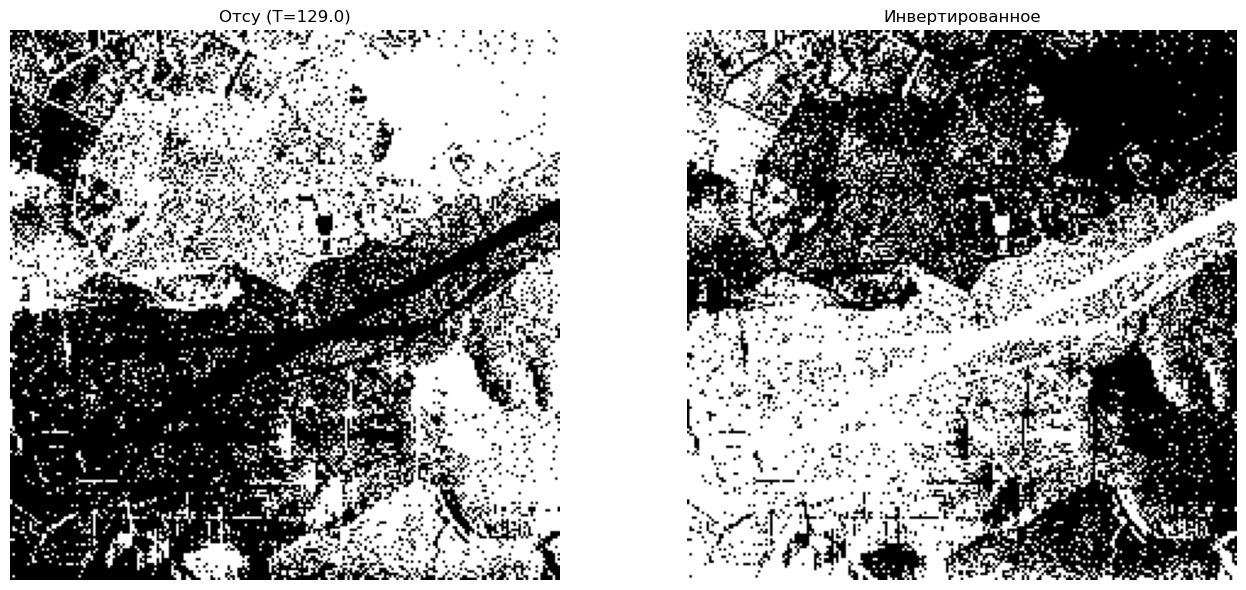

In [5]:
t_otsu, bin_otsu = cv2.threshold(image_gray, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Оптимальный порог Отсу: T = {t_otsu}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(bin_otsu, cmap='gray')
axes[0].set_title(f'Отсу (T={t_otsu})')
axes[1].imshow(cv2.bitwise_not(bin_otsu), cmap='gray')
axes[1].set_title('Инвертированное')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

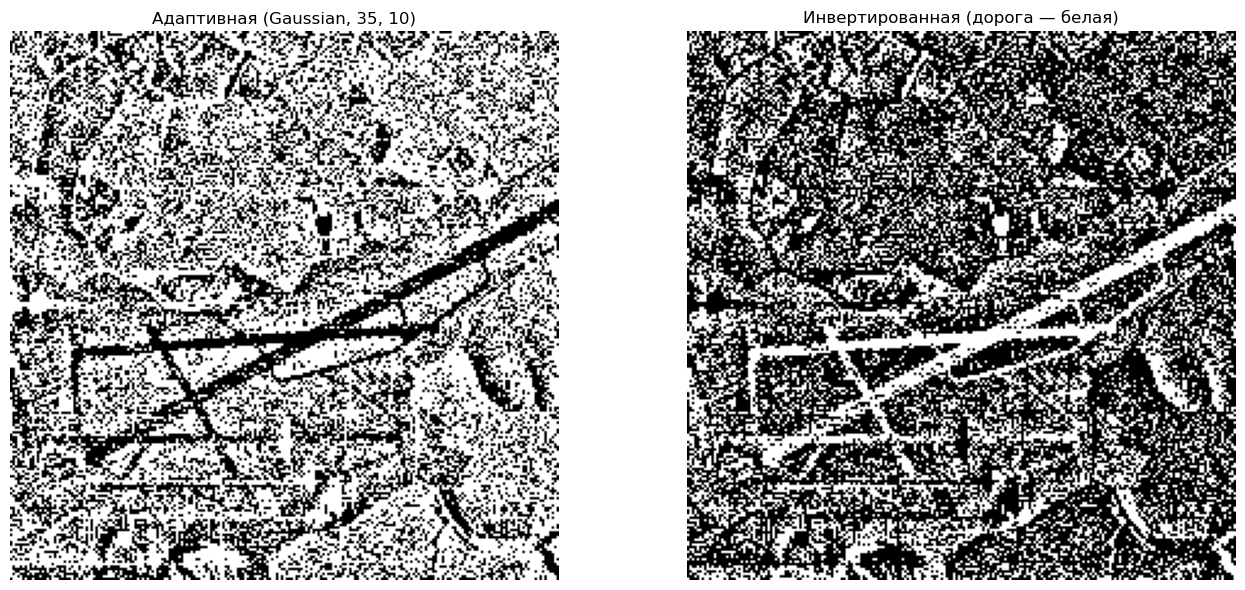

In [6]:
th_adapt = cv2.adaptiveThreshold(image_gray, 255,
                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY,
                                 blockSize=35,
                                 C=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(th_adapt, cmap='gray')
axes[0].set_title('Адаптивная (Gaussian, 35, 10)')
axes[1].imshow(cv2.bitwise_not(th_adapt), cmap='gray')
axes[1].set_title('Инвертированная (дорога — белая)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

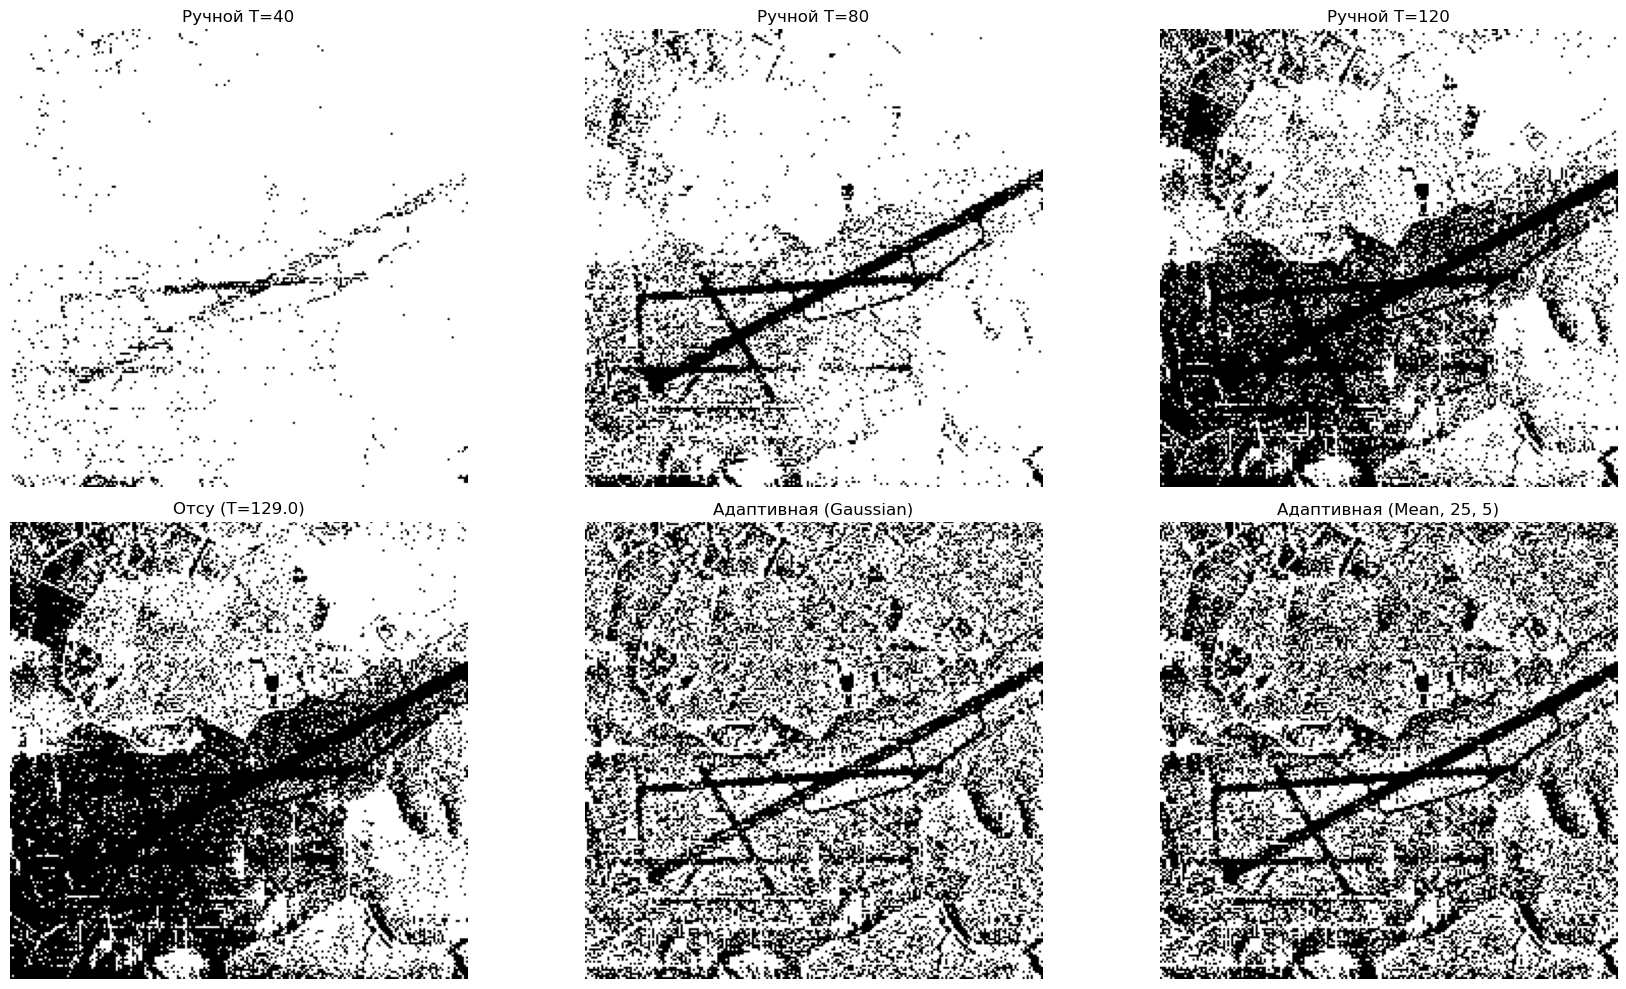

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Ручной при разных T
for ax, T_ in zip(axes[0], [40, 80, 120]):
    b = copy.deepcopy(image_gray)
    b[image_gray <  T_] = 0
    b[image_gray >= T_] = 255
    ax.imshow(b, cmap='gray')
    ax.set_title(f'Ручной T={T_}')
    ax.axis('off')

axes[1][0].imshow(bin_otsu, cmap='gray')
axes[1][0].set_title(f'Отсу (T={t_otsu})')
axes[1][0].axis('off')

axes[1][1].imshow(th_adapt, cmap='gray')
axes[1][1].set_title('Адаптивная (Gaussian)')
axes[1][1].axis('off')

th_adapt2 = cv2.adaptiveThreshold(image_gray, 255,
                                  cv2.ADAPTIVE_THRESH_MEAN_C,
                                  cv2.THRESH_BINARY, 25, 5)
axes[1][2].imshow(th_adapt2, cmap='gray')
axes[1][2].set_title('Адаптивная (Mean, 25, 5)')
axes[1][2].axis('off')

plt.tight_layout(); plt.show()

Топ-10 площадей компонент: [np.int32(392), np.int32(109), np.int32(55), np.int32(26), np.int32(22), np.int32(21), np.int32(14), np.int32(14), np.int32(11), np.int32(10)]
  Компонента 5: area=  392, aspect=3.57 ✓
  Компонента 21: area=  109, aspect=4.83 ✓

Оставлено: 2 из 24
Пикселей в маске дороги: 501


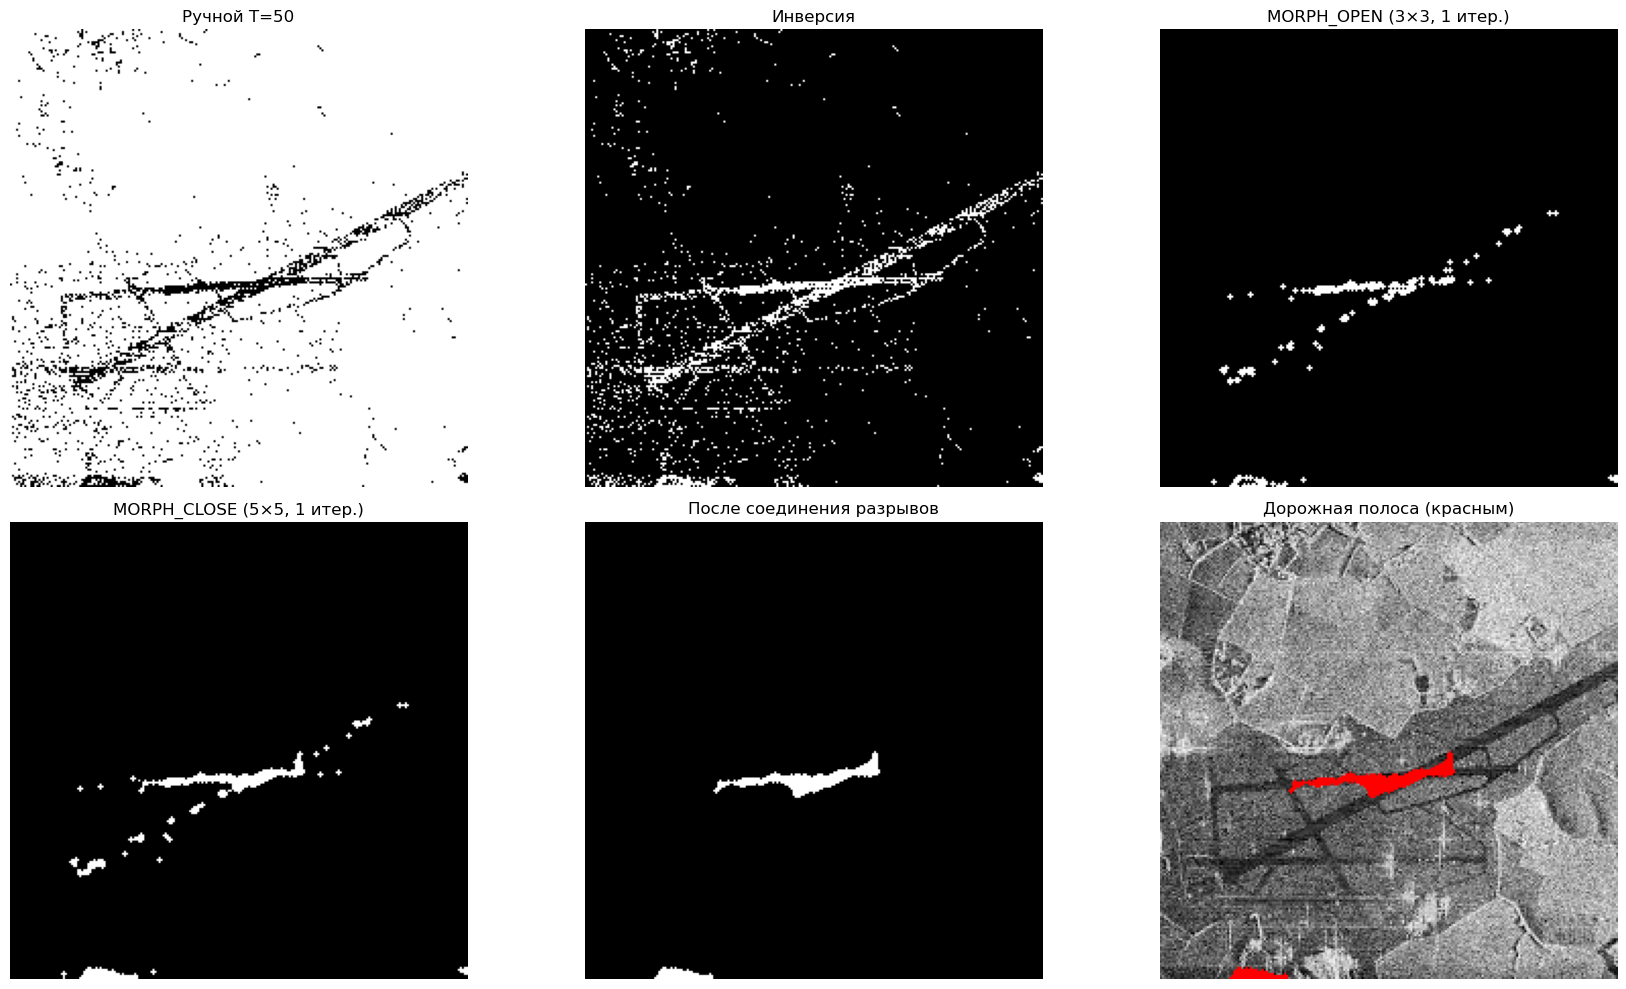

In [11]:
# Берём инвертированную ручную бинаризацию
road_mask = cv2.bitwise_not(bin_img)

# === Морфология (аккуратная, чтобы не убить тонкую дорогу) ===
# Ядро 3×3, всего 1 итерация — щадящий режим
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
opened = cv2.morphologyEx(road_mask, cv2.MORPH_OPEN, kernel, iterations=1)

# Закрытие 5×5 закрывает разрывы дороги
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel2, iterations=1)

# === Фильтр по площади ===
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed)

# Диагностика
areas = sorted([stats[i, cv2.CC_STAT_AREA] for i in range(1, num_labels)],
               reverse=True)
print("Топ-10 площадей компонент:", areas[:10])

# === Ключевое изменение: понижаем min_area и добавляем фильтр по вытянутости ===
min_area = 30       # было 100 — дорога разбита на куски по 30-80 пикс.
road_clean = np.zeros_like(closed)
kept = 0

for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    aspect = max(w, h) / max(1, min(w, h))   # вытянутость

    # Дорога: протяжённая И вытянутая
    if area >= min_area and aspect >= 2.5:
        road_clean[labels == i] = 255
        kept += 1
        print(f"  Компонента {i}: area={area:5}, aspect={aspect:.2f} ✓")

print(f"\nОставлено: {kept} из {num_labels-1}")
print(f"Пикселей в маске дороги: {int((road_clean > 0).sum())}")

# === Дополнительно: соединяем близкие куски дороги морфологией ===
# Дилатация 5×5 потом эрозия — соединит разрывы, не размывая
road_clean_closed = cv2.morphologyEx(road_clean, cv2.MORPH_CLOSE,
                                     cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)),
                                     iterations=2)

# === Наложение на исходное ===
result = image.copy()
result[road_clean_closed == 255] = [0, 0, 255]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0][0].imshow(bin_img, cmap='gray')
axes[0][0].set_title('Ручной T=50'); axes[0][0].axis('off')

axes[0][1].imshow(road_mask, cmap='gray')
axes[0][1].set_title('Инверсия'); axes[0][1].axis('off')

axes[0][2].imshow(opened, cmap='gray')
axes[0][2].set_title('MORPH_OPEN (3×3, 1 итер.)'); axes[0][2].axis('off')

axes[1][0].imshow(closed, cmap='gray')
axes[1][0].set_title('MORPH_CLOSE (5×5, 1 итер.)'); axes[1][0].axis('off')

axes[1][1].imshow(road_clean_closed, cmap='gray')
axes[1][1].set_title('После соединения разрывов'); axes[1][1].axis('off')

axes[1][2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1][2].set_title('Дорожная полоса (красным)')
axes[1][2].axis('off')

plt.tight_layout(); plt.show()

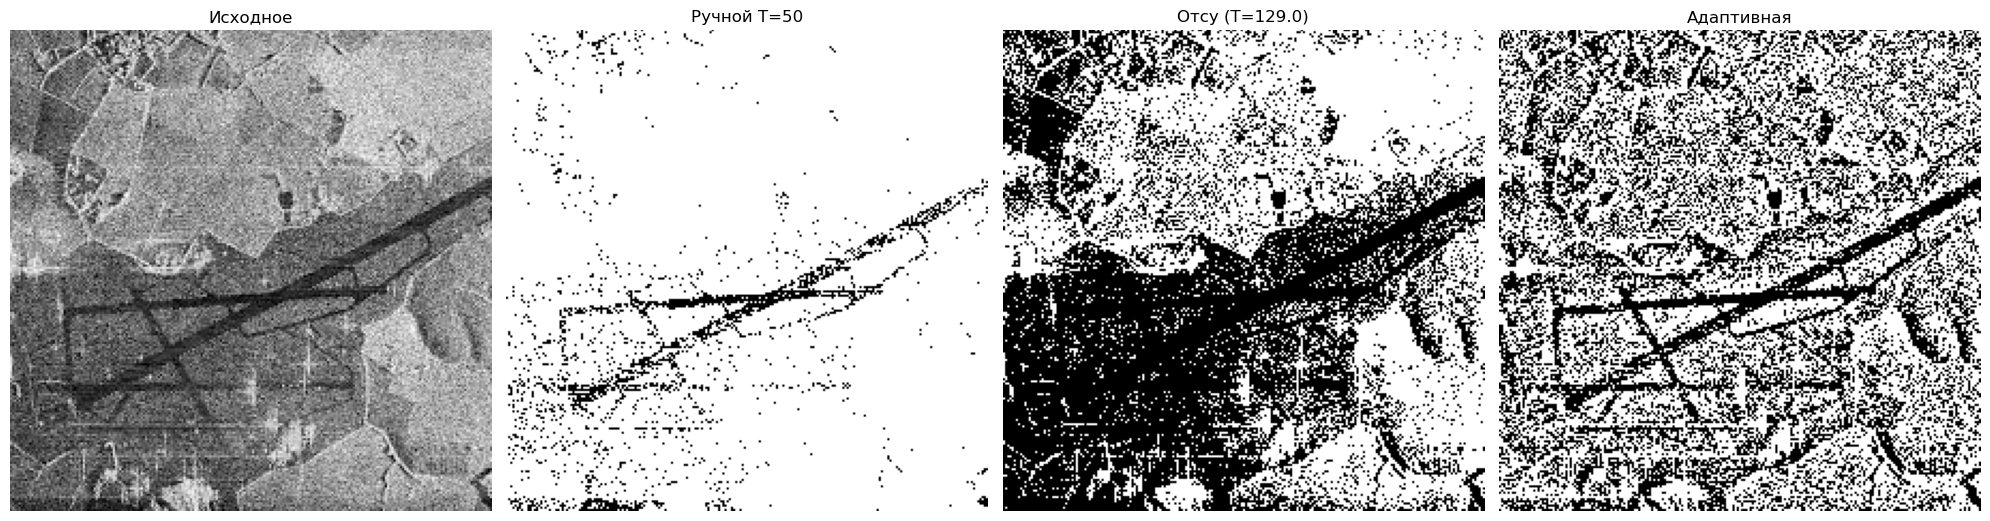

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

axes[0].imshow(image_gray, cmap='gray'); axes[0].set_title('Исходное')
axes[1].imshow(bin_img, cmap='gray');    axes[1].set_title(f'Ручной T={T}')
axes[2].imshow(bin_otsu, cmap='gray');   axes[2].set_title(f'Отсу (T={t_otsu})')
axes[3].imshow(th_adapt, cmap='gray');   axes[3].set_title('Адаптивная')

for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()